# Etapa 2 – CNN com PyTorch
Classificação de cães e gatos usando Rede Neural Convolucional implementada com PyTorch e TorchVision.
**Sem** modelos pré-treinados — arquitetura definida do zero.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import time

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("CUDA disponível:", torch.cuda.is_available())
print("Usando:", DEVICE)

CUDA disponível: True
Usando: cuda


## Configurações e Hiperparâmetros

In [2]:
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE   = 32
EPOCHS       = 20
LEARNING_RATE = 0.001
DATASET_DIR  = 'datasets'   # ajuste se necessário
NUM_CLASSES  = 2            # cat=0, dog=1

print(f'Dispositivo: {DEVICE}')

Dispositivo: cuda


## Pré-processamento e Data Augmentation

Aplicamos **três técnicas de grupos diferentes**, conforme exigido:
1. **Geométrico** – `RandomHorizontalFlip`
2. **Rotação** – `RandomRotation(10°)`
3. **Cor** – `ColorJitter` (brilho, contraste, saturação)

Imagens redimensionadas para 224×224 em RGB (3 canais).

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # 1. Geométrico
    transforms.RandomHorizontalFlip(),
    # 2. Rotação
    transforms.RandomRotation(10),
    # 3. Cor
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

## Carregamento do Dataset

In [4]:
import os

train_dataset = datasets.ImageFolder(os.path.join(DATASET_DIR, 'train'),      transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATASET_DIR, 'validation'), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATASET_DIR, 'test'),       transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Classes: {train_dataset.classes}')   # ['cat', 'dog']
print(f'Train: {len(train_dataset)} imagens')
print(f'Val:   {len(val_dataset)} imagens')
print(f'Test:  {len(test_dataset)} imagens')

Classes: ['cat', 'dog']
Train: 300 imagens
Val:   100 imagens
Test:  100 imagens


## Definição da Arquitetura CNN

Arquitetura customizada com:
- **3 blocos convolucionais** (Conv → BN → ReLU → MaxPool)
- **1 camada Dropout** para regularização
- **2 camadas fully connected** na saída

In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()

        # Bloco 1: 3 → 32 canais, 224x224 → 112x112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 224 → 112
        )

        # Bloco 2: 32 → 64 canais, 112x112 → 56x56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 112 → 56
        )

        # Bloco 3: 64 → 128 canais, 56x56 → 28x28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)   # 56 → 28
        )

        # Classificador: 128 * 28 * 28 → 256 → num_classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


model     = CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Resumo simples
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParâmetros treináveis: {total_params:,}')

CNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Lin

## Treinamento

In [6]:
train_losses = []
val_losses   = []

start = time.time()

for epoch in range(EPOCHS):
    # ========================
    # TREINO
    # ========================
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ========================
    # VALIDAÇÃO
    # ========================
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f'Época {epoch+1:2d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

end = time.time()
training_time = end - start
print(f'\nTempo de treinamento: {training_time:.2f}s')

Época  1/20 | Train Loss: 23.1818 | Val Loss: 13.2821
Época  2/20 | Train Loss: 10.7731 | Val Loss: 8.3841
Época  3/20 | Train Loss: 3.8919 | Val Loss: 1.1157
Época  4/20 | Train Loss: 2.2191 | Val Loss: 1.7339
Época  5/20 | Train Loss: 0.8580 | Val Loss: 0.8519
Época  6/20 | Train Loss: 0.6416 | Val Loss: 0.8755
Época  7/20 | Train Loss: 0.6365 | Val Loss: 0.8676
Época  8/20 | Train Loss: 0.6999 | Val Loss: 0.7926
Época  9/20 | Train Loss: 0.5952 | Val Loss: 0.7787
Época 10/20 | Train Loss: 0.6313 | Val Loss: 0.7589
Época 11/20 | Train Loss: 0.5742 | Val Loss: 0.7950
Época 12/20 | Train Loss: 0.5624 | Val Loss: 0.8366
Época 13/20 | Train Loss: 0.5979 | Val Loss: 0.8211
Época 14/20 | Train Loss: 0.5545 | Val Loss: 0.8434
Época 15/20 | Train Loss: 0.5496 | Val Loss: 0.8780
Época 16/20 | Train Loss: 0.5452 | Val Loss: 0.8509
Época 17/20 | Train Loss: 0.7111 | Val Loss: 1.2382
Época 18/20 | Train Loss: 0.5789 | Val Loss: 0.7335
Época 19/20 | Train Loss: 0.5824 | Val Loss: 0.7687
Época 20/

## Avaliação no Conjunto de Teste

In [7]:
model.eval()
correct    = 0
total      = 0
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs   = model(images)
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Acurácia no teste: {accuracy:.2f}%')
print(f'Tempo de treinamento: {training_time:.2f}s')

Acurácia no teste: 64.00%
Tempo de treinamento: 155.54s


## Matriz de Confusão

In [8]:
cm = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

print('Matriz de Confusão:')
print(f'              Predito Gato  Predito Cachorro')
print(f'Real Gato         {TN:5d}          {FP:5d}')
print(f'Real Cachorro     {FN:5d}          {TP:5d}')

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'\nPrecisão:  {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Matriz de Confusão:
              Predito Gato  Predito Cachorro
Real Gato            33             17
Real Cachorro        19             31

Precisão:  0.6458
Recall:    0.6200
F1-Score:  0.6327


## Gráfico de Loss (Treino vs Validação)

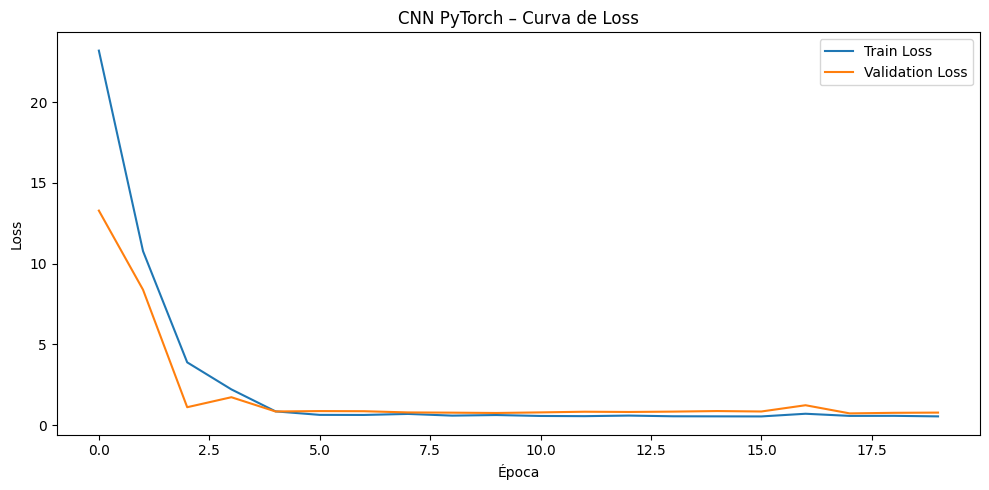

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.title('CNN PyTorch – Curva de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## GERACAO DE RELATORIO

In [10]:
import datetime

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

relatorio = f"""================================================================
RELATÓRIO – ETAPA 2: CNN COM PYTORCH
Gerado em: {datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')}
================================================================

CONFIGURAÇÕES
-------------
Dispositivo         : {DEVICE}
Tamanho da imagem   : 224x224 (RGB, 3 canais)
Batch size          : {BATCH_SIZE}
Épocas              : {EPOCHS}
Learning rate       : {LEARNING_RATE}
Otimizador          : Adam
Função de perda     : CrossEntropyLoss
Total de parâmetros : {total_params:,}
Parâm. treináveis   : {trainable_params:,}

ARQUITETURA
-----------
Bloco 1 : Conv(3→32)  + BatchNorm + ReLU + MaxPool  →  112x112
Bloco 2 : Conv(32→64) + BatchNorm + ReLU + MaxPool  →  56x56
Bloco 3 : Conv(64→128)+ BatchNorm + ReLU + MaxPool  →  28x28
FC      : Flatten → Linear(100352→256) → ReLU → Dropout(0.5) → Linear(256→2)

DATA AUGMENTATION
-----------------
1. RandomHorizontalFlip   (geométrico)
2. RandomRotation(10°)    (rotação)
3. ColorJitter            (cor: brilho, contraste, saturação)

DATASET
-------
Amostras de treino      : {len(train_dataset)}
Amostras de validação   : {len(val_dataset)}
Amostras de teste       : {len(test_dataset)}
Total                   : {len(train_dataset) + len(val_dataset) + len(test_dataset)}
Classes                 : {train_dataset.classes}

RESULTADOS DO TREINAMENTO
--------------------------
Loss final (treino)     : {train_losses[-1]:.4f}
Loss final (validação)  : {val_losses[-1]:.4f}
Loss mínima (treino)    : {min(train_losses):.4f} (época {train_losses.index(min(train_losses))+1})
Loss mínima (validação) : {min(val_losses):.4f} (época {val_losses.index(min(val_losses))+1})
Tempo de treinamento    : {training_time:.2f} segundos

RESULTADOS NO TESTE
--------------------
Acurácia   : {accuracy:.2f}%
Precisão   : {precision:.4f}
Recall     : {recall:.4f}
F1-Score   : {f1:.4f}

MATRIZ DE CONFUSÃO
-------------------
                  Predito Gato   Predito Cachorro
Real Gato             {TN:5d}            {FP:5d}
Real Cachorro         {FN:5d}            {TP:5d}

  TP (acertou cachorro) : {TP}
  TN (acertou gato)     : {TN}
  FP (gato → cachorro)  : {FP}
  FN (cachorro → gato)  : {FN}
================================================================
"""

print(relatorio)

with open('relatorio_cnn.txt', 'w', encoding='utf-8') as f:
    f.write(relatorio)

print('Relatório salvo em: relatorio_cnn.txt')

RELATÓRIO – ETAPA 2: CNN COM PYTORCH
Gerado em: 22/06/2026 18:55:59

CONFIGURAÇÕES
-------------
Dispositivo         : cuda
Tamanho da imagem   : 224x224 (RGB, 3 canais)
Batch size          : 32
Épocas              : 20
Learning rate       : 0.001
Otimizador          : Adam
Função de perda     : CrossEntropyLoss
Total de parâmetros : 25,784,578
Parâm. treináveis   : 25,784,578

ARQUITETURA
-----------
Bloco 1 : Conv(3→32)  + BatchNorm + ReLU + MaxPool  →  112x112
Bloco 2 : Conv(32→64) + BatchNorm + ReLU + MaxPool  →  56x56
Bloco 3 : Conv(64→128)+ BatchNorm + ReLU + MaxPool  →  28x28
FC      : Flatten → Linear(100352→256) → ReLU → Dropout(0.5) → Linear(256→2)

DATA AUGMENTATION
-----------------
1. RandomHorizontalFlip   (geométrico)
2. RandomRotation(10°)    (rotação)
3. ColorJitter            (cor: brilho, contraste, saturação)

DATASET
-------
Amostras de treino      : 300
Amostras de validação   : 100
Amostras de teste       : 100
Total                   : 500
Classes               